In [1]:
!pip install --upgrade scikit-learn scikit-learn==1.7.1 xgboost==3.0.3 lightgbm==4.6.0 numpy==1.26.4 scipy==1.14.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.8/253.8 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 36.6 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.5.0
    Uninstalling lightgbm-4.5.0:
      Succ

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, label_binarize, OrdinalEncoder, QuantileTransformer, TargetEncoder
from category_encoders import CatBoostEncoder, MEstimateEncoder

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.linear_model import RidgeClassifier, LogisticRegression, LinearRegression, BayesianRidge, Ridge

from sklearn import set_config
import os

import optuna
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, root_mean_squared_error, mean_squared_error, precision_recall_curve, make_scorer, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, matthews_corrcoef
from scipy.stats import norm, skew

from colorama import Fore, Style, init
from copy import deepcopy
from sklearn.base import BaseEstimator, TransformerMixin
from pprint import pprint
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold, KFold, RepeatedKFold, cross_val_score, StratifiedGroupKFold
from xgboost import DMatrix, XGBClassifier, XGBRegressor
from lightgbm import log_evaluation, early_stopping, LGBMClassifier, LGBMRegressor, Dataset
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from tqdm.notebook import tqdm
from optuna.samplers import TPESampler, CmaEsSampler
from optuna.pruners import HyperbandPruner
from functools import partial
from IPython.display import display_html, clear_output
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
import gc
import re
from typing import Literal, NamedTuple
from itertools import combinations

import keras
from keras.models import Sequential
from keras import layers
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings("ignore")

2025-09-01 06:15:27.503850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756707327.752562      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756707327.826406      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


**Description**

* **age**: Age of the client (numeric)
* **job**: Type of job (categorical: "admin.", "blue-collar", "entrepreneur", etc.)
* **marital**: Marital status (categorical: "married", "single", "divorced")
* **education**: Level of education (categorical: "primary", "secondary", "tertiary", "unknown")
* **default**: Has credit in default? (categorical: "yes", "no")
* **balance**: Average yearly balance in euros (numeric)
* **housing**: Has a housing loan? (categorical: "yes", "no")
* **loan**: Has a personal loan? (categorical: "yes", "no")
* **contact**: Type of communication contact (categorical: "unknown", "telephone", "cellular")
* **day**: Last contact day of the month (numeric, 1-31)
* **month**: Last contact month of the year (categorical: "jan", "feb", "mar", …, "dec")
* **duration**: Last contact duration in seconds (numeric)
* **campaign**: Number of contacts performed during this campaign (numeric)
**pdays**: Number of days since the client was last contacted from a previous campaign (numeric; -1 means the client was not previously contacted)
* **previous**: Number of contacts performed before this campaign (numeric)
* **poutcome**: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")
* **y**: The target variable, whether the client subscribed to a term deposit (binary: 0, 1)

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Configuration</p>

In [3]:
class Config:
    
    state = 42
    n_splits = 10
    early_stop = 100
        
    target = 'y'
    train = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv', index_col='id')
    test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv', index_col='id')
    submission = pd.read_csv('/kaggle/input/playground-series-s5e8/sample_submission.csv')
    train_org = pd.read_csv('/kaggle/input/bank-marketing-dataset-full/bank-full.csv', sep=';')
    
    original_data = True
    outliers = False
    log_trf = False
    feature_eng = False
    missing = False
    labels = list(train[target].unique())

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">EDA</p>

In [4]:
class EDA(Config):
    
    def __init__(self):
        super().__init__()

        self.cat_features = self.train.drop(self.target, axis=1).select_dtypes(include=['object']).columns.tolist()
        self.num_features = self.train.drop(self.target, axis=1).select_dtypes(exclude=['object']).columns.tolist()
        self.data_info()
        self.heatmap()
        self.dist_plots()
        self.cat_feature_plots()
        self.target_pie()
                
    def data_info(self):
        
        for data, label in zip([self.train, self.test], ['Train', 'Test']):
            table_style = [{'selector': 'th:not(.index_name)',
                            'props': [('background-color', '#3cb371'),
                                      ('color', '#FFFFFF'),
                                      ('font-weight', 'bold'),
                                      ('border', '1px solid #DCDCDC'),
                                      ('text-align', 'center')]
                            }, 
                            {'selector': 'tbody td',
                             'props': [('border', '1px solid #DCDCDC'),
                                       ('font-weight', 'normal')]
                            }]
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} head\n')
            display(data.head().style.set_table_styles(table_style))
                           
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} info\n'+Style.RESET_ALL)               
            display(data.info())
                           
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} describe\n')
            display(data.describe().drop(index='count', columns=self.target, errors = 'ignore').T
                    .style.set_table_styles(table_style).format('{:.3f}'))
            
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} missing values\n'+Style.RESET_ALL)               
            display(data.isna().sum())
        return self
    
    def heatmap(self):
        print(Style.BRIGHT+Fore.GREEN+f'\nCorrelation Heatmap\n')
        plt.figure(figsize=(7,7))
        corr = self.train.select_dtypes(exclude='object').corr(method='pearson')
        sns.heatmap(corr, fmt = '0.4f', cmap = 'Greens', annot=True, cbar=False)
        plt.show()
        
    def dist_plots(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nDistribution analysis\n")
        df = pd.concat([self.train[self.num_features].assign(Source = 'Train'), 
                        self.test[self.num_features].assign(Source = 'Test'),], 
                        axis=0, ignore_index = True)

        fig, axes = plt.subplots(len(self.num_features), 2 ,figsize = (18, len(self.num_features) * 6), 
                                 gridspec_kw = {'hspace': 0.3, 
                                                'wspace': 0.2, 
                                                'width_ratios': [0.70, 0.30]
                                               }
                                )
        for i,col in enumerate(self.num_features):
            ax = axes[i,0]
            sns.kdeplot(data = df[[col, 'Source']], x = col, hue = 'Source', 
                        palette = ['#3cb371', 'r'], ax = ax, linewidth = 2
                       )
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col}")
            ax.grid()

            ax = axes[i,1]
            sns.boxplot(data = df, y = col, x=df.Source, width = 0.5,
                        linewidth = 1, fliersize= 1,
                        ax = ax, palette=['#3cb371', 'r']
                       )
            ax.set_title(f"\n{col}")
            ax.set(xlabel = '', ylabel = '')
            ax.tick_params(axis='both', which='major')
            ax.set_xticklabels(['Train', 'Test'])

        plt.tight_layout()
        plt.show()
               
    def cat_feature_plots(self):
        fig, axes = plt.subplots(max(len(self.cat_features), 1), 2 ,figsize = (18, len(self.cat_features) * 6), 
                                 gridspec_kw = {'hspace': 0.5, 
                                                'wspace': 0.2,
                                               }
                                )
        if len(self.cat_features) == 1:
            axes = np.array([axes])
            
        for i, col in enumerate(self.cat_features):
            ax = axes[i,0]
            sns.barplot(data=self.train[col].value_counts().nlargest(10).reset_index(), x=col, y='count', ax=ax, color='#3cb371')
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col} Train")
            
            ax = axes[i,1]
            sns.barplot(data=self.train[col].value_counts().nlargest(10).reset_index(), x=col, y='count', ax=ax, color='r')
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col} Test")

        plt.tight_layout()
        plt.show()

    def target_pie(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nTarget feature distribution\n")
        targets = self.train[self.target]
        plt.figure(figsize=(6, 6))
        plt.pie(targets.value_counts(), labels=targets.value_counts().index, autopct='%1.2f%%', colors=sns.color_palette('viridis', len(targets.value_counts())))
        plt.show()


Train head



,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1



Train info

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
 16  y          750000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 103.0+ MB


None


Train describe



...


Test describe



,mean,std,min,25%,50%,75%,max
age,40.932,10.082,18.000,33.000,39.000,48.000,95.000
balance,1197.426,2741.521,-8019.000,0.000,631.000,1389.000,98517.000
day,16.116,8.259,1.000,9.000,17.000,21.000,31.000
duration,255.342,271.404,3.000,91.000,133.000,353.000,4918.000
campaign,2.574,2.710,1.000,1.000,2.000,3.000,58.000
pdays,22.280,76.916,-1.000,-1.000,-1.000,-1.000,871.000
previous,0.304,1.385,0.000,0.000,0.000,0.000,150.000



Test missing values



age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
dtype: int64


Correlation Heatmap



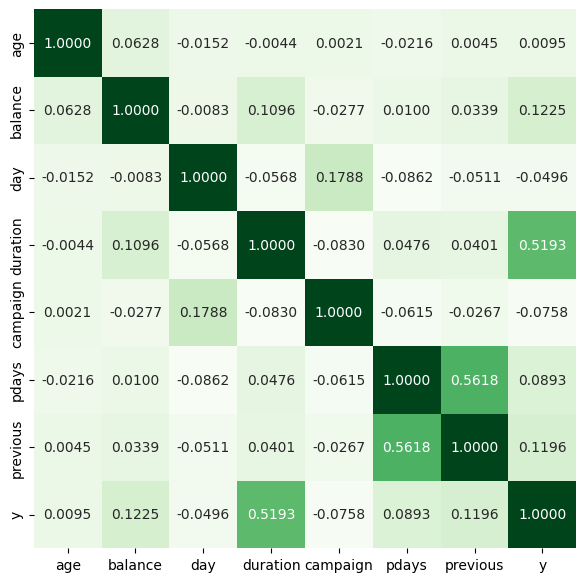


Distribution analysis



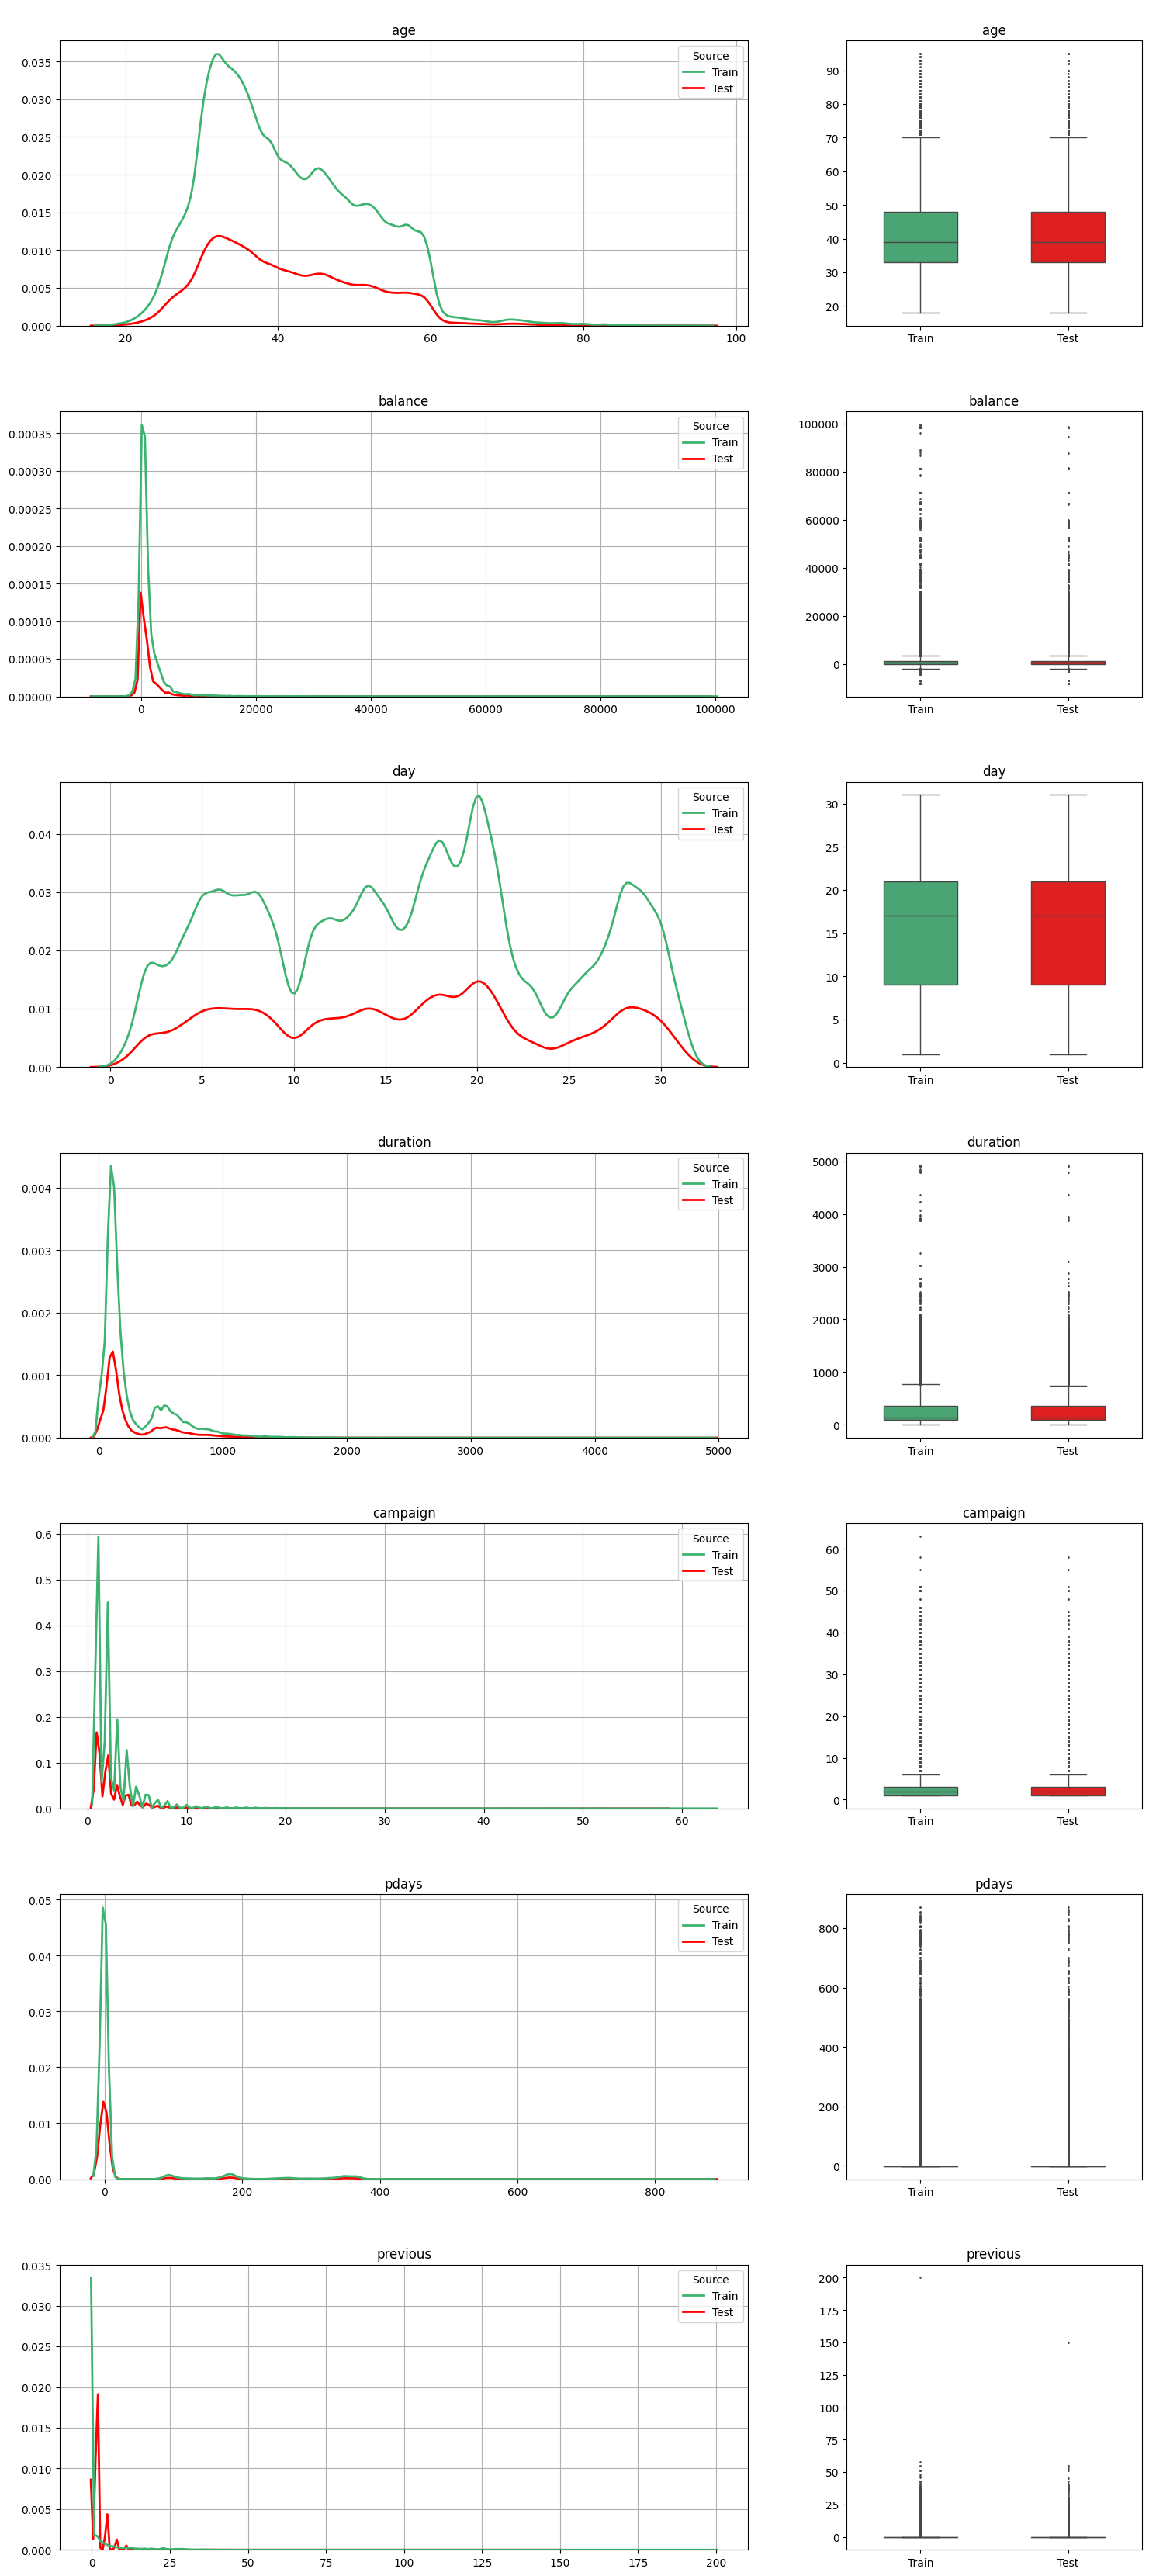

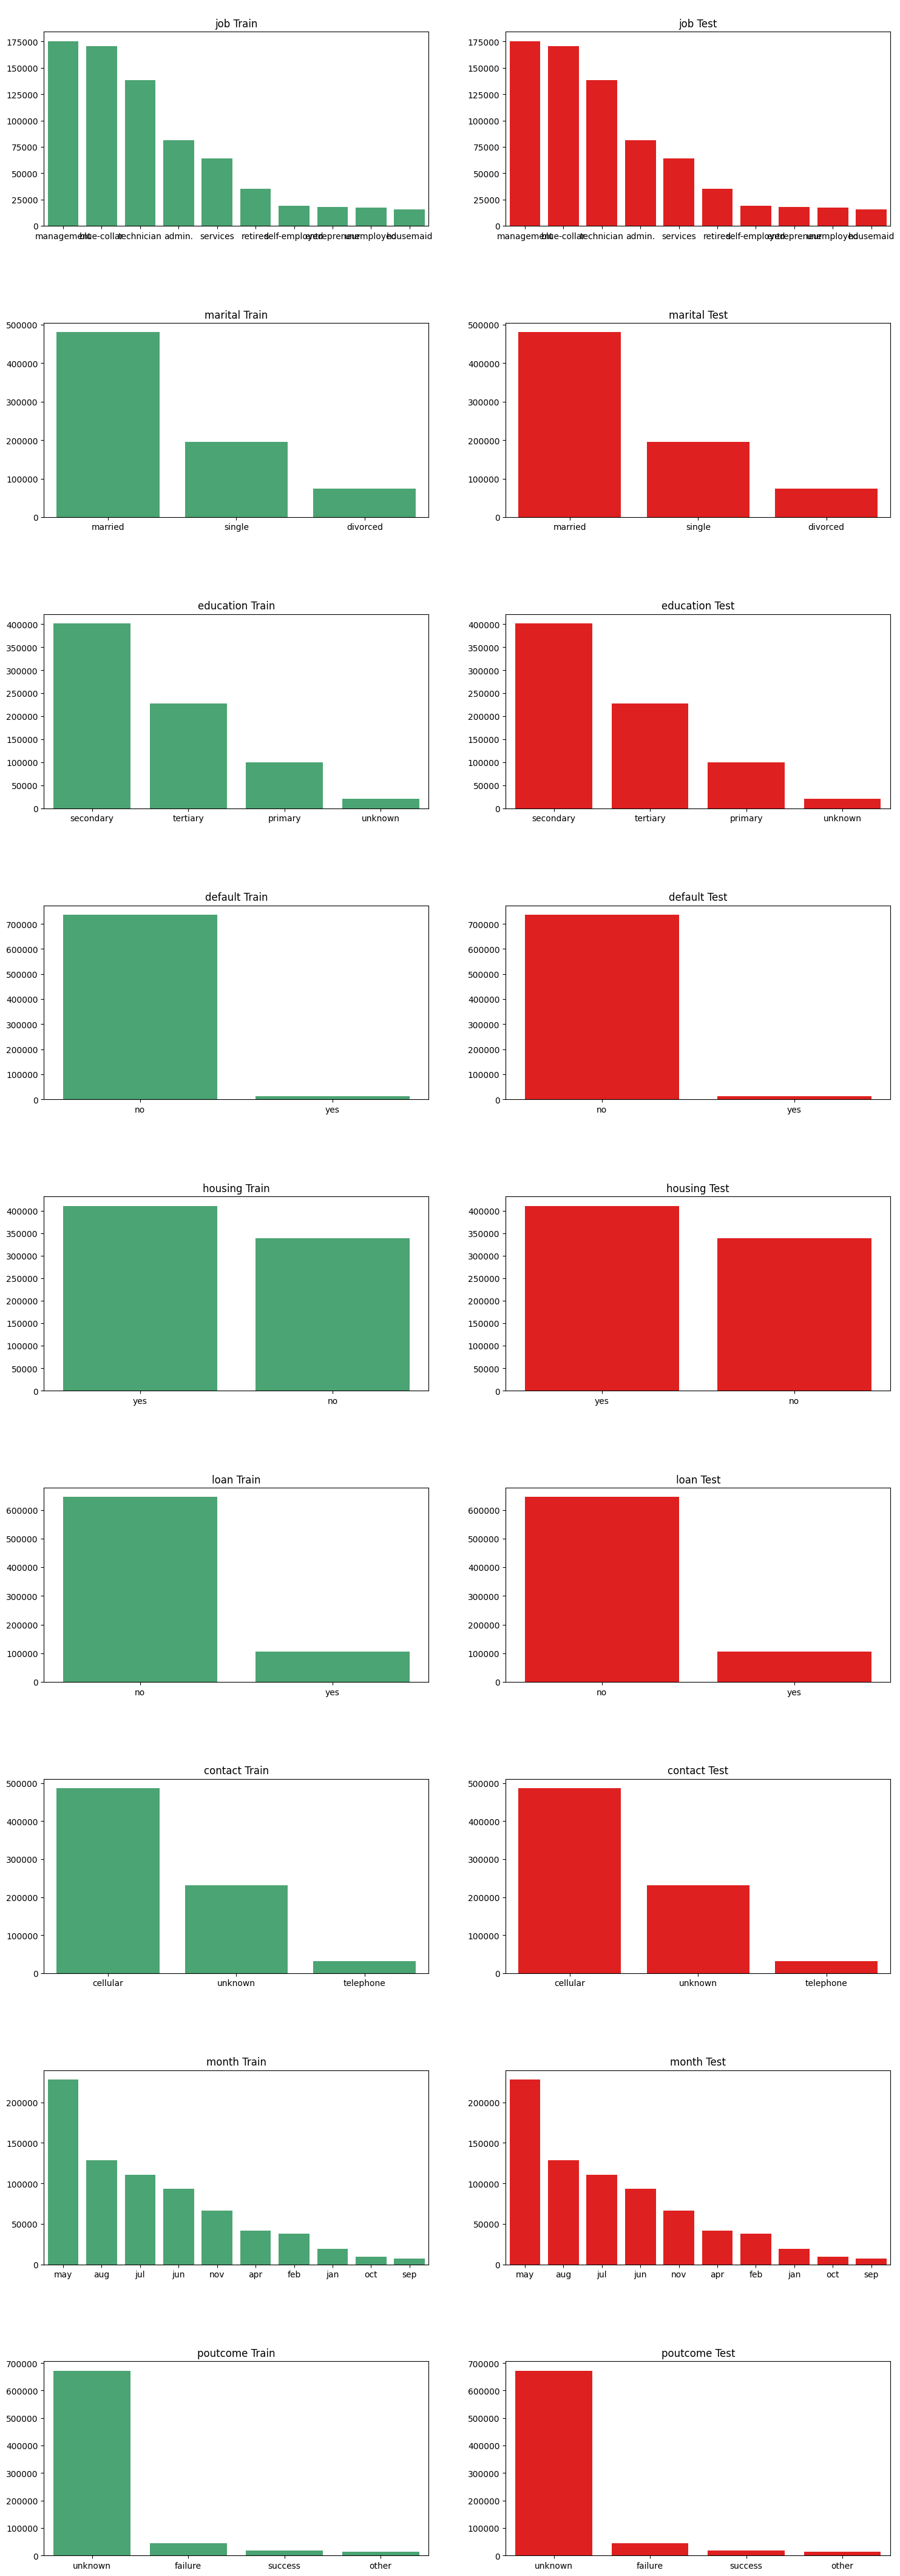


Target feature distribution



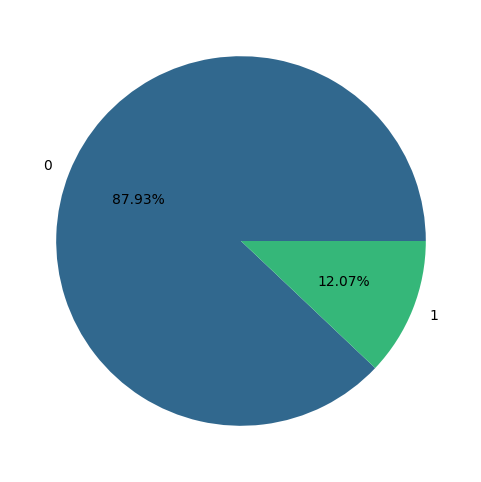

In [5]:
eda = EDA()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Data Transformation</p>

In [6]:
class Transform(Config):
    
    def __init__(self):
        super().__init__()
        if self.original_data:
            self.train_org[self.target] = (self.train_org[self.target]=="yes").astype(int)
            
        self.num_features = self.train.drop(self.target, axis=1).select_dtypes(exclude=['object', 'bool']).columns.tolist()
        self.cat_features = self.train.drop(self.target, axis=1).columns.tolist()

        if self.missing:
            self.missing_values()
        
        if self.feature_eng:
            self.train = self.new_features(self.train)
            self.test = self.new_features(self.test)
            self.train_org = self.new_features(self.train_org)
            
            self.num_features = self.train.drop(self.target, axis=1).select_dtypes(exclude=['object', 'bool', 'string', 'category']).columns.tolist()
            
        if self.outliers:    
            self.remove_outliers()
            
        if self.log_trf:
            self.log_transformation()
            
        self.encode()
        
    def __call__(self):

        self.y = self.train[self.target]        
        self.X = self.train.drop(self.target, axis=1)
        self.X_enc = self.train_enc.drop(self.target, axis=1)

        return self.X, self.X_enc, self.y, self.test, self.test_enc, self.cat_features, self.num_features
    
    def encode(self):
        self.train_enc = self.train.copy()
        self.test_enc = self.test.copy()
        
        self.cat_features_card = []
        for f in self.cat_features:
            self.cat_features_card.append(self.train[f].nunique())
            
        data = pd.concat([self.train_enc, self.test_enc])
        oe = OrdinalEncoder()
        data[self.cat_features] = oe.fit_transform(data[self.cat_features]).astype('int')
        
        scaler = StandardScaler()
        data[self.num_features] = scaler.fit_transform(data[self.num_features])

        self.train_enc = data[~data[self.target].isna()]
        self.test_enc = data[data[self.target].isna()].drop(self.target, axis=1)
            
    def new_features(self, data):
        
        for c1, c2 in list(combinations(self.num_features,2)):
            data[f"{c1}_{c2}"] = data[c1]*data[c2]
            
        data['balance_log'] = np.sign(data['balance']) * np.log1p(np.abs(data['balance']))
        data['duration_log'] = np.log1p(data['duration'])
        data['duration_sin'] = np.sin(2*np.pi * data['duration'] / 540)

        data[self.cat_features] = data[self.cat_features].astype('category')
        
        for cols in list(combinations(self.cat_features, 2)):
            new_col_name = '_'.join(cols)+'_enc'            
            data[new_col_name] = data[list(cols)].astype(str).agg('_'.join, axis=1).astype('string')
        return data

    def log_transformation(self):
        self.train[self.target] = np.log1p(self.train[self.target]) 
        
        return self
        
    def remove_outliers(self):
        Q1 = self.train[self.targets].quantile(0.25)
        Q3 = self.train[self.targets].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5*IQR
        upper_limit = Q3 + 1.5*IQR
        self.train = self.train[(self.train[self.targets] >= lower_limit) & (self.train[self.targets] <= upper_limit)]
        self.train.reset_index(drop=True, inplace=True)
    
    def missing_values(self):
        self.train[self.cat_features] = self.train[self.cat_features].fillna('NaN')
        self.test[self.cat_features] = self.test[self.cat_features].fillna('NaN')
        return self

    def reduce_mem(self, df):

        numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64', "uint16", "uint32", "uint64"]
        
        for col in df.columns:
            col_type = df[col].dtypes
            
            if col_type in numerics:
                c_min = df[col].min()
                c_max = df[col].max()

                if "int" in str(col_type):
                    if c_min >= np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min >= np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min >= np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min >= np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)  
                else:
                    if c_min >= np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                        df[col] = df[col].astype(np.float16)
                    if c_min >= np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
                    else:
                        df[col] = df[col].astype(np.float64)  

        return df

In [7]:
t = Transform()
X, X_enc, y, test, test_enc, cat_features, num_features = t()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Model Training</p>

**Neural Network model**

In [8]:
def build_model(cat_features, num_features):
    
    x_input_cats = layers.Input(shape=(len(cat_features),))
    embs = []
    for j in range(len(cat_features)):
        e = layers.Embedding(t.cat_features_card[j], int(np.ceil(np.sqrt(t.cat_features_card[j]))))
        x = e(x_input_cats[:,j])
        x = layers.Flatten()(x)
        embs.append(x)
        
    x_input_nums = layers.Input(shape=(len(num_features),))
    
    x = layers.Concatenate(axis=-1)(embs+[x_input_nums]) 
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(.3)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(.3)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(.3)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inputs=[x_input_cats,x_input_nums], outputs=x)
    return model

**YDF model**

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
import contextlib, io
import ydf; ydf.verbose(2)
from ydf import RandomForestLearner

def YDFClassification(learner_class):

    class YDFXClassifier(BaseEstimator, ClassifierMixin):

        def __init__(self, params=None):
            self.params = {} if params is None else params.copy()

        def fit(self, X: pd.DataFrame, y: pd.Series):
            assert isinstance(X, pd.DataFrame)
            assert isinstance(y, pd.Series)

            self.classes_ = list(y.unique())
            self.n_classes_ = len(self.classes_)

            target = y.name
            params = self.params.copy()
            params['label'] = target
            params['task'] = ydf.Task.CLASSIFICATION

            df = pd.concat([X, y], axis=1)

            with contextlib.redirect_stdout(io.StringIO()), \
                 contextlib.redirect_stderr(io.StringIO()):
                self.model = learner_class(**params).train(df)

            return self

        def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
            assert isinstance(X, pd.DataFrame)

            with contextlib.redirect_stdout(io.StringIO()), \
                 contextlib.redirect_stderr(io.StringIO()):
                raw = self.model.predict(X)

            proba = np.asarray(raw)
            if proba.ndim == 1:
                proba = np.vstack([1 - proba, proba]).T

            return proba

        def predict(self, X: pd.DataFrame) -> np.ndarray:
            proba = self.predict_proba(X)
            idx = proba.argmax(axis=1)
            return np.array(self.classes_)[idx]

    return YDFXClassifier

In [10]:
models = {
    'XGB': XGBClassifier(**{'tree_method': 'hist',
                            'n_estimators': 10000,
                            'objective': 'binary:logistic',
                            'random_state': Config.state,
                            'enable_categorical': True,
                            'early_stopping_rounds': Config.early_stop,
                            'eval_metric': 'auc',
                            'booster': 'gbtree',
                            'n_jobs': -1,
                            'lambda': 4.510522889747622,
                            'alpha': 5.007953193043952, 
                            'colsample_bytree': 0.5831655543160346,
                            'subsample': 0.9808690492838653,
                            'learning_rate': 0.008247101477015132,
                            'max_depth': 11,
                            'min_child_weight': 1,
                            'device': 'cuda',
                            }),
    'XGB2': XGBClassifier(**{'tree_method': 'hist',
                            'n_estimators': 10000,
                            'objective': 'binary:logistic',
                            'random_state': Config.state,
                            'enable_categorical': True,
                            'early_stopping_rounds': Config.early_stop,
                            'eval_metric': 'auc',
                            'booster': 'gbtree',
                            'n_jobs': -1,
                            'lambda': 6.0745670939974135, 
                            'alpha': 2.5748720110585968, 
                            'colsample_bytree': 0.45797036043254047, 
                            'subsample': 0.989774122876245,
                            'learning_rate': 0.01139415349606075,
                            'max_depth': 9, 
                            'min_child_weight': 4,
                            'device': 'cuda'
                            }),
    'XGB3': XGBClassifier(**{'tree_method': 'hist',
                            'n_estimators': 10000,
                            'objective': 'binary:logistic',
                            'random_state': Config.state,
                            'enable_categorical': True,
                            'early_stopping_rounds': Config.early_stop,
                            'eval_metric': 'auc',
                            'booster': 'gbtree',
                            'n_jobs': -1,
                            'lambda': 4.501285168764996,
                            'alpha': 4.687579918561145,
                            'colsample_bytree': 0.388546328230297, 
                            'subsample': 0.9761959719581299,
                            'learning_rate': 0.015696594335680082, 
                            'max_depth': 11,
                            'min_child_weight': 6,
                            'device': 'cuda'
                            }),
    'XGB6': XGBClassifier(),
    'LGBM': LGBMClassifier(**{'random_state': Config.state,
                              'early_stopping_round': Config.early_stop,
                              'verbose': -1,
                              'n_estimators': 10000,
                              'metric': 'AUC',
                              'objective': 'binary',
                              'max_depth': 16,
                              'learning_rate': 0.007366917567300051,
                              'min_child_samples': 164,
                              'subsample': 0.9022880020285295,
                              'colsample_bytree': 0.4213201532077694,
                              'num_leaves': 122, 
                              'reg_alpha': 1.083996192298843,
                              'reg_lambda': 0.0700057221912873
                              }),
    'LGBM2': LGBMClassifier(**{'random_state': Config.state,
                               'early_stopping_round': Config.early_stop,
                               'verbose': -1,
                               'n_estimators': 10000,
                               'metric': 'AUC',
                               'objective': 'binary',
                               'max_depth': 19,
                               'learning_rate': 0.010196940756517232,
                               'min_child_samples': 40,
                               'subsample': 0.5388367974706456,
                               'colsample_bytree': 0.24506890759293215,
                               'num_leaves': 360, 
                               'reg_alpha': 0.11493527242956506,
                               'reg_lambda': 0.8048854866109955
                              }),
    'LGBM3': LGBMClassifier(**{'random_state': Config.state,
                               'early_stopping_round': Config.early_stop,
                               'verbose': -1,
                               'n_estimators': 5000,
                               'metric': 'AUC',
                               'objective': 'binary',
                               'boosting_type': 'goss',
                               'max_depth': 18,
                               'learning_rate': 0.013632406163139255,
                               'min_child_samples': 76,
                               'subsample': 0.8008906838837987,
                               'colsample_bytree': 0.22001761604503337,
                               'num_leaves': 345, 
                               'reg_alpha': 1.616390930105809,
                               'reg_lambda': 0.6118370655549995
                              }),
    'LGBM4': LGBMClassifier(**{'random_state': Config.state,
                               'early_stopping_round': Config.early_stop,
                               'verbose': -1,
                               'n_estimators': 5000,
                               'objective': 'binary',
                               'max_depth': 15, 
                               'learning_rate': 0.022467627035973214,
                               'min_child_samples': 67,
                               'subsample': 0.7559251319436844,
                               'colsample_bytree': 0.2000581740451036, 
                               'num_leaves': 246, 
                               'reg_alpha': 2.5588798826484718,
                               'reg_lambda': 0.6531036609824434,
                               'metric': 'binary_logloss',
                               'max_bin': 8000
                              }),
    'CAT': CatBoostClassifier(**{'random_state': Config.state,
                                 'cat_features': cat_features,
                                 'early_stopping_rounds': Config.early_stop,
                                 'eval_metric': "Logloss",
                                 'n_estimators' : 5000,
                                 'learning_rate': 0.06524873965257823,
                                 'l2_leaf_reg': 0.8867612905712001,
                                 'bagging_temperature': 0.1317347791955057,
                                 'random_strength': 0.9922857768340815,
                                 'depth': 7,
                                 'min_data_in_leaf': 8,
                                 'task_type': "GPU"
                                 }),
    'CAT2': CatBoostClassifier(**{'random_state': Config.state,
                                  'cat_features': cat_features,
                                  'early_stopping_rounds': Config.early_stop,
                                  'eval_metric': "Logloss",
                                  'n_estimators' : 5000,
                                  'learning_rate': 0.034582298874165696,
                                  'l2_leaf_reg': 0.9838795180512044,
                                  'bagging_temperature': 0.22069473702418926,
                                  'random_strength': 1.0557491242401338,
                                  'depth': 9,
                                  'min_data_in_leaf': 166,
                                  'task_type': "GPU"
                                 }),
    'CAT3': CatBoostClassifier(**{'random_state': Config.state,
                                  'cat_features': cat_features,
                                  'early_stopping_rounds': Config.early_stop,
                                  'eval_metric': "AUC",
                                  'n_estimators' : 5000,
                                  'learning_rate': 0.022110492120285524,
                                  'l2_leaf_reg': 0.2536752778357197, 
                                  'bagging_temperature': 2.292041314766286, 
                                  'random_strength': 1.982204530407152,
                                  'depth': 11,
                                  'min_data_in_leaf': 265,
                                  'task_type': "GPU"
                                  }),
    'YDF': YDFClassification(RandomForestLearner)({'num_trees': 1000,
                                                   'max_depth': 30,
                                                   'random_seed': Config.state,
                                                   'growing_strategy': 'BEST_FIRST_GLOBAL'
                                               }),
    'NN2': _
}

In [11]:
class Trainer(Config):
    
    def __init__(self, X, X_enc, y, test, test_enc, models, training=True):
        self.X = X
        self.X_enc = X_enc
        self.test = test
        self.test_enc = test_enc
        self.y = y
        self.X_original = t.train_org.drop(columns=[self.target])
        self.y_original = t.train_org[self.target]
        self.models = models
        self.training = training
        self.scores = pd.DataFrame(columns=['Score'])
        self.OOF_preds = pd.DataFrame(dtype=float)
        self.TEST_preds = pd.DataFrame(dtype=float)
        self.folds = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=self.state)
    
    def train(self, model, X, y, test, model_name):
        oof_pred = np.zeros(X.shape[0], dtype=float)
        test_pred = np.zeros(test.shape[0], dtype=float)

        print('='*20)
        print(model_name)
                
        for n_fold, (train_id, valid_id) in enumerate(self.folds.split(X, y)):
            X_train = X.loc[train_id].copy()
            y_train = y.iloc[train_id]
            X_val = X.loc[valid_id].copy()
            y_val = y.iloc[valid_id]
            X_test = test.copy()
            
            if model_name != 'Ensemble':
                X_train = pd.concat([X_train, self.X_original], axis=0, ignore_index=True)
                y_train = pd.concat([y_train, self.y_original], axis=0, ignore_index=True)
    
                X_train[cat_features] = X_train[cat_features].astype("category")
                X_val[cat_features] = X_val[cat_features].astype("category")
                X_test[cat_features] = X_test[cat_features].astype("category")
    
                encoded_columns = [col for col in X.columns if '_enc' in col]
                te = TargetEncoder(random_state=42)
                            
                X_train[encoded_columns] = te.fit_transform(X_train[encoded_columns], y_train).astype('float32')
                X_val[encoded_columns] = te.transform(X_val[encoded_columns]).astype('float32')
                X_test[encoded_columns] = te.transform(X_test[encoded_columns]).astype('float32')
                
            print(f'Fold {n_fold+1}')
            
            if 'NN' in model_name:
                X_train_cats = X_train[cat_features]
                X_train_nums = X_train[num_features]

                X_val_cats = X_val[cat_features]
                X_val_nums = X_val[num_features]

                X_test_cats = X_test[cat_features]
                X_test_nums = X_test[num_features]
                
                model = build_model(cat_features, num_features)                        
                keras.utils.set_random_seed(self.state)
                optimizer = keras.optimizers.AdamW(learning_rate=1e-2, weight_decay=1e-3)
                model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['auc'])
                
                model.fit([X_train_cats,X_train_nums], y_train, 
                          validation_data=([X_val_cats, X_val_nums], y_val),
                          epochs=20,
                          batch_size=1000,
                          callbacks=[keras.callbacks.ReduceLROnPlateau(patience=1),
                                     keras.callbacks.EarlyStopping(patience=3)
                                    ])
                y_pred_val = model.predict([X_val_cats, X_val_nums]).squeeze()                      
                test_pred += model.predict([X_test_cats, X_test_nums]).squeeze() / self.n_splits             
                                      
            else:
                if "XGB" in model_name or "CAT" in model_name:
                    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                
                elif "LGBM" in model_name:
                    model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
                              categorical_feature=cat_features,
                              feature_name='auto',
                              callbacks=[log_evaluation(0),early_stopping(self.early_stop, verbose=False)]
                             )
                    
                else:                           
                    model.fit(X_train, y_train)
                    
                y_pred_val = model.predict_proba(X_val)[:, 1]            
                test_pred += model.predict_proba(X_test)[:, 1] / self.n_splits
                
            oof_pred[valid_id] = y_pred_val
            score = roc_auc_score(y_val, y_pred_val)
            print(score)
            self.scores.loc[f'{model_name}', f'Fold {n_fold+1}'] = score                                      

        self.scores.loc[f'{model_name}', 'Score'] = self.scores.loc[f'{model_name}'][1:].mean()

        return oof_pred, test_pred

    def run(self):
        for model_name, model in tqdm(self.models.items()):

            if self.training:                
                if any(model in model_name for model in ['LGBM', 'CAT', 'XGB', 'HGB', 'YDF']):
                    X = self.X.copy()
                    test = self.test.copy()
                else:
                    X = self.X_enc.copy()
                    test = self.test_enc.copy()

                oof_pred, test_pred = self.train(model, X, y, test, model_name)
                pd.DataFrame(oof_pred, columns=[f'{model_name}']).to_csv(f'{model_name}_oof.csv', index=False)
                pd.DataFrame(test_pred, columns=[f'{model_name}']).to_csv(f'{model_name}_test.csv', index=False)
            
            else:
                oof_pred = pd.read_csv(f'/kaggle/input/bank-class-models/{model_name}_oof.csv')
                test_pred = pd.read_csv(f'/kaggle/input/bank-class-models/{model_name}_test.csv')
                for n_fold, (train_id, valid_id) in enumerate(self.folds.split(oof_pred, self.y)):
                    y_pred_val, y_val = oof_pred.loc[valid_id], self.y.loc[valid_id]
                    self.scores.loc[f'{model_name}', f'Fold {n_fold+1}'] = roc_auc_score(y_val, y_pred_val)
                self.scores.loc[f'{model_name}', 'Score'] = self.scores.loc[f'{model_name}'][1:].mean()

            self.OOF_preds[f'{model_name}'] = oof_pred
            self.TEST_preds[f'{model_name}'] = test_pred
            
        if len(self.models)>1:
            meta_model = LogisticRegression(C = 0.1, random_state = self.state, max_iter = 1000)
            self.OOF_preds["Ensemble"], self.TEST_preds["Ensemble"] = self.train(meta_model, self.OOF_preds, y, self.TEST_preds, 'Ensemble')
            self.scores = self.scores.sort_values('Score')
            self.score_bar()
            self.plot_result(self.OOF_preds["Ensemble"])
            return self.TEST_preds["Ensemble"]
        else:
            print(Style.BRIGHT+Fore.GREEN+f'{model_name} score {self.scores.loc[f"{model_name}", "Score"]:.5f}\n')
            self.plot_result(self.OOF_preds[f'{model_name}'])
            return self.TEST_preds[f'{model_name}']

    def score_bar(self):
        plt.figure(figsize=(18, 6))      
        colors = ['#3cb371' if i != 'Ensemble' else 'r' for i in self.scores.Score.index]
        hbars = plt.barh(self.scores.index, self.scores.Score, color=colors, height=0.8)
        plt.bar_label(hbars, fmt='%.6f')
        plt.xlim(0.8, 1)
        plt.ylabel('Models')
        plt.xlabel('Score')
        plt.show()
        
    def plot_result(self, oof):           
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))

        for col in self.OOF_preds:
            RocCurveDisplay.from_predictions(self.y.sort_index(), self.OOF_preds[col], name=f"{col}", ax=axes[0])            
        axes[0].plot([0, 1], [0, 1], linestyle='--', lw=2, color='black')
        axes[0].set_xlabel('False Positive Rate')
        axes[0].set_ylabel('True Positive Rate')
        axes[0].set_title('ROC')
        axes[0].legend(loc="lower right")
        
        ConfusionMatrixDisplay.from_predictions(y.sort_index(), (oof>=0.5).astype(int), display_labels=self.labels, colorbar=False, ax=axes[1], cmap = 'Greens')
        axes[1].set_title('Confusion Matrix')
        
        plt.tight_layout()
        plt.show()

  0%|          | 0/13 [00:00<?, ?it/s]

Ensemble
Fold 1
0.9781229045929393
Fold 2
0.9765358650033399
Fold 3
0.9764355671427056
Fold 4
0.9767805776042393
Fold 5
0.9758016328940194
Fold 6
0.9762874783488337
Fold 7
0.9772617011348063
Fold 8
0.9766961392768185
Fold 9
0.9769141654994469
Fold 10
0.9764303157195007


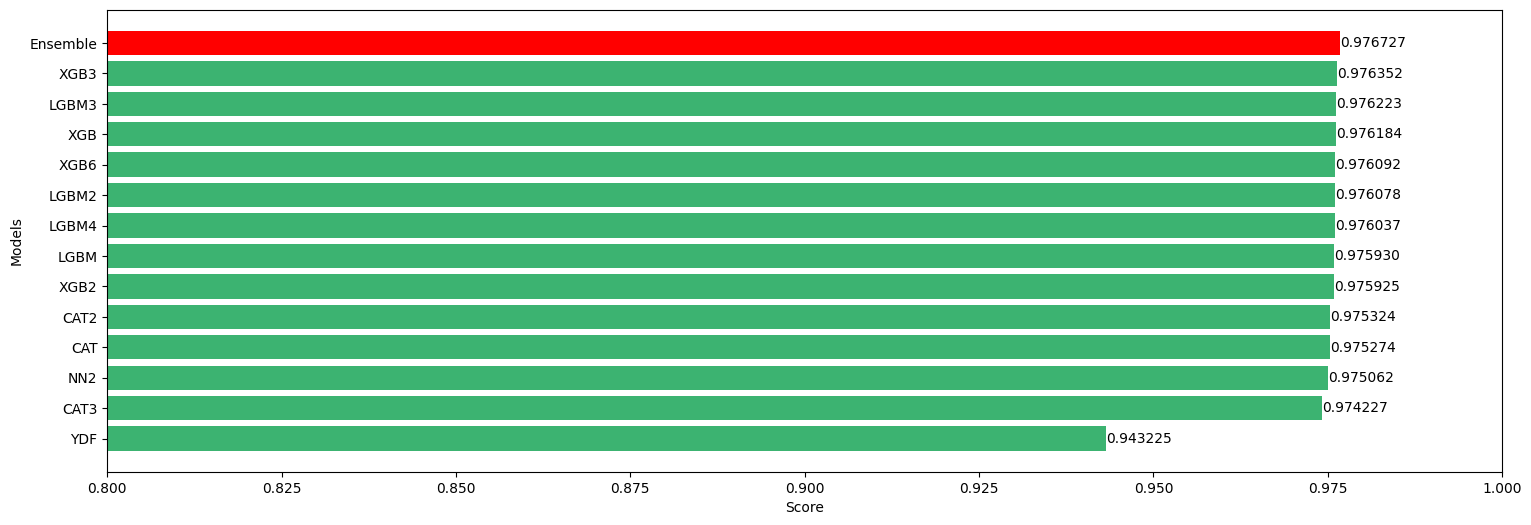

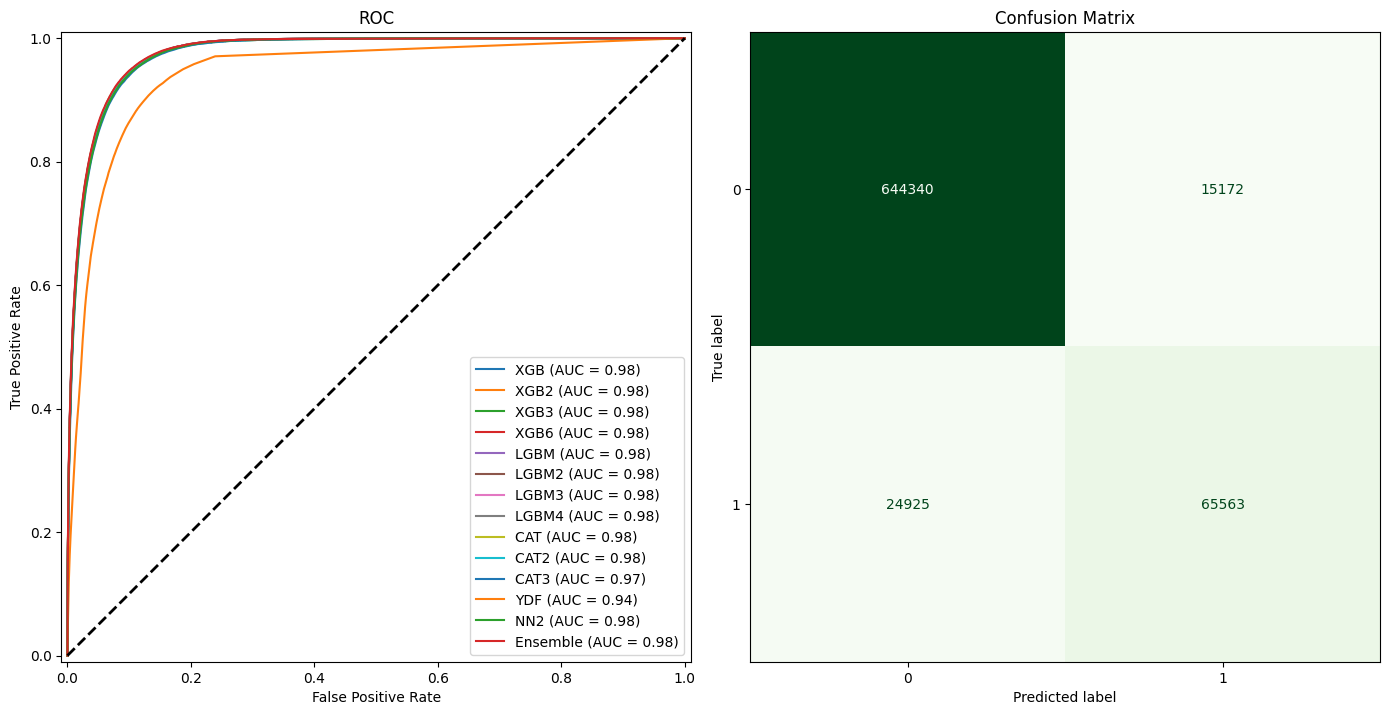

In [12]:
trainer = Trainer(X, X_enc, y, test, test_enc, models, training=False)
TEST_preds = trainer.run()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Submission</p>

,id,y
0,750000,0.015293
1,750001,0.025294
2,750002,0.015220
3,750003,0.015205
4,750004,0.015956


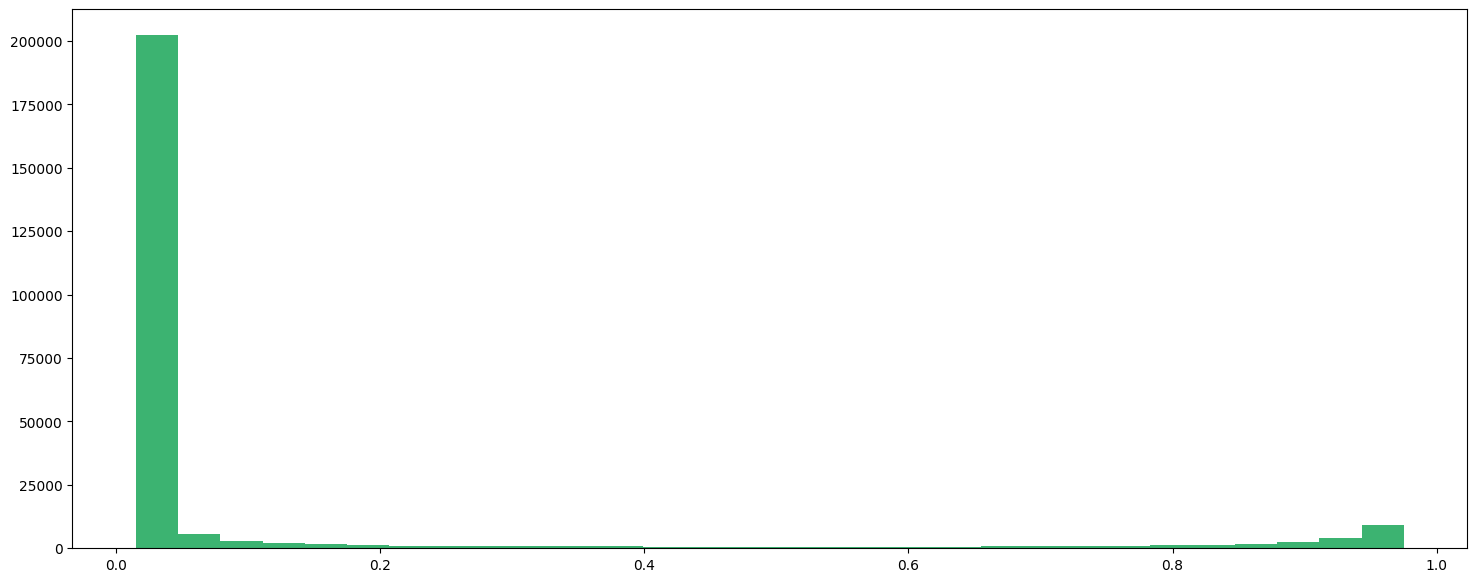

In [13]:
submission = Config.submission
submission[Config.target] = TEST_preds
submission.to_csv("submission.csv", index=False)

display(submission.head())
plt.figure(figsize=(18, 7))
plt.hist(submission[Config.target], bins=30, color='#3cb371')
plt.show()